In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/cleaned/cleaned_flights_no_weather_disruption.csv")
print(df.shape)
df.head()

(280387, 22)


,carrier_code,date,flight_number,tail_number,destination_airport,scheduled_departure_time,actual_departure_time,scheduled_elapsed_time_minutes,actual_elapsed_time_minutes,departure_delay_minutes,...,delay_carrier_minutes,delay_weather_minutes,delay_national_aviation_system_minutes,delay_security_minutes,delay_late_aircraft_arrival_minutes,origin_airport,month,day_of_week,departure_hour,delayed_15
0,B6,2025-01-01,100.0,N2188J,FLL,10:43,10:34,302.0,282.0,-9.0,...,0.0,0.0,0.0,0.0,0.0,LAX,1,Wednesday,10,0
1,B6,2025-01-01,200.0,N982JB,FLL,23:05,23:12,291.0,288.0,7.0,...,0.0,0.0,0.0,0.0,0.0,LAX,1,Wednesday,23,0
2,B6,2025-01-01,288.0,N2156J,BOS,11:05,10:52,325.0,316.0,-13.0,...,0.0,0.0,0.0,0.0,0.0,LAX,1,Wednesday,11,0
3,B6,2025-01-01,388.0,N2180J,BOS,20:39,20:32,322.0,298.0,-7.0,...,0.0,0.0,0.0,0.0,0.0,LAX,1,Wednesday,20,0
4,B6,2025-01-01,424.0,N2165J,JFK,06:35,06:21,324.0,296.0,-14.0,...,0.0,0.0,0.0,0.0,0.0,LAX,1,Wednesday,6,0


>There are almost 300k flights, resulting in some operations taking extremely long to complete.
> I will be using a sample of 10000 for now 

In [3]:
df = df.sample(10000, random_state=69420)
df.head()

,carrier_code,date,flight_number,tail_number,destination_airport,scheduled_departure_time,actual_departure_time,scheduled_elapsed_time_minutes,actual_elapsed_time_minutes,departure_delay_minutes,...,delay_carrier_minutes,delay_weather_minutes,delay_national_aviation_system_minutes,delay_security_minutes,delay_late_aircraft_arrival_minutes,origin_airport,month,day_of_week,departure_hour,delayed_15
185211,DL,2025-07-28,1551.0,N3736C,SEA,19:59,20:58,165.0,150.0,59.0,...,44.0,0.0,0.0,0.0,0.0,LAX,7,Monday,19,1
151813,UA,2025-03-06,1924.0,N76519,DEN,18:50,18:49,145.0,123.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,SAN,3,Thursday,18,0
190602,DL,2025-09-19,692.0,N345NW,AUS,18:50,18:47,178.0,172.0,-3.0,...,0.0,0.0,0.0,0.0,0.0,LAX,9,Friday,18,0
253510,UA,2025-07-22,1111.0,N37368,LIH,08:35,08:33,336.0,326.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,SFO,7,Tuesday,8,0
51560,AA,2025-01-26,2018.0,N456AN,PHL,11:25,11:23,309.0,288.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,LAX,1,Sunday,11,0


### Linear regression

We want to predict departure_delay_minutes based off of some subset of our covariates. Let's start off with most of the covariates to get a baseline reading for our model performance. 

The following covariates were ignored:
* The date covariate due to redundancy with month and day_of_week.
* tail_number due to solely being an identifier
* scheduled_departure_time, actual_departure_time, wheels_off_time due to redundancy with departure_hour

In [4]:
formula = 'departure_delay_minutes ~ C(carrier_code) + flight_number + C(destination_airport) + scheduled_elapsed_time_minutes + actual_elapsed_time_minutes + taxi_out_time_minutes + delay_carrier_minutes + delay_weather_minutes + delay_national_aviation_system_minutes + delay_security_minutes + delay_late_aircraft_arrival_minutes + C(origin_airport) + C(month) + C(day_of_week) + departure_hour + C(delayed_15)'

model = smf.ols(formula, data=df.head(100)).fit()

print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     departure_delay_minutes   R-squared:                       0.998
Model:                                 OLS   Adj. R-squared:                  0.993
Method:                      Least Squares   F-statistic:                     209.9
Date:                     Fri, 05 Jun 2026   Prob (F-statistic):           1.81e-31
Time:                             20:34:48   Log-Likelihood:                -264.91
No. Observations:                      100   AIC:                             663.8
Df Residuals:                           33   BIC:                             838.4
Df Model:                               66                                         
Covariance Type:                 nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

Some p-values seem high and the statsmodels OLS note tells us that there might be multicollinearity problems. We can check the Variance Inflation Factors to test for this.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# this code was based off of lecture slides
exog = model.model.exog
names = model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

VIF: C(carrier_code)[T.AS]:  12.904
VIF: C(carrier_code)[T.B6]:  9.619
VIF: C(carrier_code)[T.DL]:  12.997
VIF: C(carrier_code)[T.UA]:  9.410
VIF: C(destination_airport)[T.AUS]:  12.437
VIF: C(destination_airport)[T.BNA]:  10.789
VIF: C(destination_airport)[T.BOS]:  18.209
VIF: C(destination_airport)[T.CLE]:  3.652
VIF: C(destination_airport)[T.CLT]:  25.554
VIF: C(destination_airport)[T.DEN]:  44.643
VIF: C(destination_airport)[T.DFW]:  37.490
VIF: C(destination_airport)[T.DTW]:  8.986
VIF: C(destination_airport)[T.EWR]:  13.330
VIF: C(destination_airport)[T.FLL]:  12.899
VIF: C(destination_airport)[T.HNL]:  19.877
VIF: C(destination_airport)[T.IAD]:  16.894
VIF: C(destination_airport)[T.IAH]:  20.246
VIF: C(destination_airport)[T.IND]:  4.861
VIF: C(destination_airport)[T.JAC]:  10.749
VIF: C(destination_airport)[T.JFK]:  14.105
VIF: C(destination_airport)[T.LAS]:  12.180
VIF: C(destination_airport)[T.LAX]:  12.579
VIF: C(destination_airport)[T.LIH]:  9.186
VIF: C(destination_airport

c:\Users\NewUser\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Multiple covariates have VIFs over 10, and some are nan implying they are perfectly collinear. We could try to simply remove variables like scheduled_elapsed_time_minutes which are obviously overlapping with other variables. 

However, for the other variables, using a variable selection technique could address the multicollinearity while also narrowing down the most important covariates.

We shall be using shrinkage methods with the LASSO penalty.

In [6]:
formula = 'departure_delay_minutes ~ C(carrier_code) + flight_number + C(destination_airport) + actual_elapsed_time_minutes + taxi_out_time_minutes + delay_carrier_minutes + delay_weather_minutes + delay_national_aviation_system_minutes + delay_security_minutes + delay_late_aircraft_arrival_minutes + C(origin_airport) + C(month) + C(day_of_week) + departure_hour + C(delayed_15)'

Text(0, 0.5, 'coefficient')

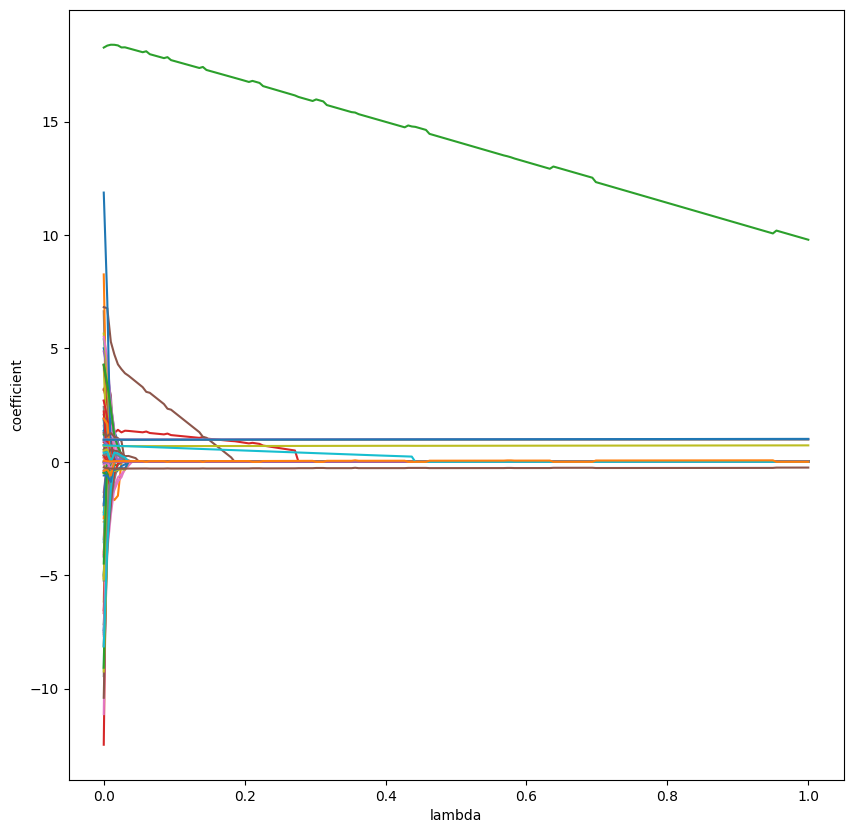

In [7]:
# this code was based off of similar code from lecture slides
lambdas = np.linspace(0, 1, 200)
elastic_coefs = []
for alpha in lambdas:
    elastic_fit = smf.ols(formula, data=df).fit_regularized(method='elastic_net', alpha=alpha, L1_wt=1.0)
    elastic_coefs.append(elastic_fit.params[1:])


# Dataframe of coefficients
elastic_coefs = pd.DataFrame(elastic_coefs, index=lambdas)
elastic_coefs


# plot each coefficient
fig, ax = plt.subplots(figsize=(10, 10))
for column in elastic_coefs.columns:
    ax.plot(lambdas, elastic_coefs[column], label=column)
ax.set_xlabel('lambda')
ax.set_ylabel('coefficient')

It seems that around $\lambda=0.5$ is our cutoff point. Let's see the model at that $\lambda$ level.

In [8]:
shrunk_model = smf.ols(formula, data=df).fit_regularized(method='elastic_net', alpha=0.5, L1_wt=1.0)

print(shrunk_model.params[shrunk_model.params != 0])

C(delayed_15)[T.1]                        14.120015
flight_number                              0.000183
actual_elapsed_time_minutes                0.003225
taxi_out_time_minutes                     -0.275522
delay_carrier_minutes                      0.996277
delay_weather_minutes                      0.974118
delay_national_aviation_system_minutes     0.711584
delay_late_aircraft_arrival_minutes        0.994300
departure_hour                             0.051841
dtype: float64


Now we can fit a model using just these covariates.

In [9]:
new_formula = "departure_delay_minutes ~ C(delayed_15) + flight_number + actual_elapsed_time_minutes + taxi_out_time_minutes + delay_carrier_minutes + delay_weather_minutes + delay_national_aviation_system_minutes + delay_late_aircraft_arrival_minutes + departure_hour"
new_model = smf.ols(new_formula, data=df).fit()
print(new_model.summary())

                               OLS Regression Results                              
Dep. Variable:     departure_delay_minutes   R-squared:                       0.977
Model:                                 OLS   Adj. R-squared:                  0.977
Method:                      Least Squares   F-statistic:                 4.707e+04
Date:                     Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                             20:38:41   Log-Likelihood:                -36055.
No. Observations:                    10000   AIC:                         7.213e+04
Df Residuals:                         9990   BIC:                         7.220e+04
Df Model:                                9                                         
Covariance Type:                 nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

Only flight number has a potentially insignificant p-value, which we could address by simply removing it.

However, when we check our VIFs, they are all below 10 now.

In [10]:
exog = new_model.model.exog
names = new_model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

VIF: C(delayed_15)[T.1]:  1.289
VIF: flight_number:  1.060
VIF: actual_elapsed_time_minutes:  1.078
VIF: taxi_out_time_minutes:  1.102
VIF: delay_carrier_minutes:  1.062
VIF: delay_weather_minutes:  1.005
VIF: delay_national_aviation_system_minutes:  1.146
VIF: delay_late_aircraft_arrival_minutes:  1.159
VIF: departure_hour:  1.009


<br></br>
<br></br>

### Logistic regression

We will now try to predict whether or not a flight will be delayed by at least 15 minutes, using logistic regression. We will be using the same covariates as our linear regression, but without the delayed_15 variable.

In [11]:
formula = "delayed_15 ~ flight_number + actual_elapsed_time_minutes + taxi_out_time_minutes + delay_carrier_minutes + delay_weather_minutes + delay_national_aviation_system_minutes + delay_late_aircraft_arrival_minutes + departure_hour"
logistic_model = smf.logit(formula, data=df).fit()
print(logistic_model.summary())

Optimization terminated successfully.
         Current function value: 0.195342
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:             delayed_15   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9991
Method:                           MLE   Df Model:                            8
Date:                Fri, 05 Jun 2026   Pseudo R-squ.:                  0.5683
Time:                        20:38:56   Log-Likelihood:                -1953.4
converged:                       True   LL-Null:                       -4525.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -2.7995  

Most of our coefficients are statistically significant, except for flight_number and actual_elapsed_time_minutes. Since both our linear regression and our logistic regression deemed flight_number as insignificant, we can remove this variable from our final results. 

However, actual_elapsed_time_minutes is only insignificant for our logistic regression, so we will only remove it from this model.

<br></br>

## Final models

### Linear regression


In [12]:
linear_formula = "departure_delay_minutes ~ C(delayed_15) + actual_elapsed_time_minutes + taxi_out_time_minutes + delay_carrier_minutes + delay_weather_minutes + delay_national_aviation_system_minutes + delay_late_aircraft_arrival_minutes + departure_hour"
linear_model = smf.ols(linear_formula, data=df).fit()
print(linear_model.summary())

                               OLS Regression Results                              
Dep. Variable:     departure_delay_minutes   R-squared:                       0.977
Model:                                 OLS   Adj. R-squared:                  0.977
Method:                      Least Squares   F-statistic:                 5.295e+04
Date:                     Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                             20:39:00   Log-Likelihood:                -36056.
No. Observations:                    10000   AIC:                         7.213e+04
Df Residuals:                         9991   BIC:                         7.219e+04
Df Model:                                8                                         
Covariance Type:                 nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

### Logistic regression

In [13]:
logistic_formula = "delayed_15 ~ taxi_out_time_minutes + delay_carrier_minutes + delay_weather_minutes + delay_national_aviation_system_minutes + delay_late_aircraft_arrival_minutes + departure_hour"
logistic_model = smf.logit(logistic_formula, data=df).fit()
print(logistic_model.summary())

Optimization terminated successfully.
         Current function value: 0.195412
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:             delayed_15   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9993
Method:                           MLE   Df Model:                            6
Date:                Fri, 05 Jun 2026   Pseudo R-squ.:                  0.5682
Time:                        20:39:05   Log-Likelihood:                -1954.1
converged:                       True   LL-Null:                       -4525.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -2.6411  